# Week 3 Practice: K-Means & Hierarchical Clustering
**Dataset:** Mall Customer Segmentation Data (Kaggle)
Link: https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python

File name after download: `Mall_Customers.csv` (place it in the same folder as this notebook)

Columns: `CustomerID`, `Gender`, `Age`, `Annual Income (k$)`, `Spending Score (1-100)`


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

## 1. Load and explore the data

In [2]:
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1000,M,39.0,59.9,58.0
1,1001,M,34.0,48.4,37.0
2,1002,F,40.0,70.5,26.0
3,1003,F,47.0,81.1,30.0
4,1004,F,33.0,42.1,58.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              1000 non-null   int64  
 1   Gender                  997 non-null    str    
 2   Age                     994 non-null    float64
 3   Annual Income (k$)      996 non-null    float64
 4   Spending Score (1-100)  994 non-null    float64
dtypes: float64(3), int64(1), str(1)
memory usage: 39.2 KB


In [4]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,1000.000000,994.000000,996.000000,994.000000
mean,1499.500000,38.935614,57.149096,42.645875
std,288.819436,13.399880,28.628506,20.101589
min,1000.000000,18.000000,15.000000,1.000000
25%,1249.750000,30.000000,34.975000,31.000000
50%,1499.500000,36.000000,49.000000,47.000000
75%,1749.250000,44.000000,79.400000,57.000000
max,1999.000000,80.000000,144.100000,92.000000


In [5]:
# We'll cluster customers based on Annual Income and Spending Score
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values
X[:5]

array([[59.9, 58. ],
       [48.4, 37. ],
       [70.5, 26. ],
       [81.1, 30. ],
       [42.1, 58. ]])

### Look at the raw data before clustering
This helps you visually confirm there's structure worth clustering before running any algorithm.

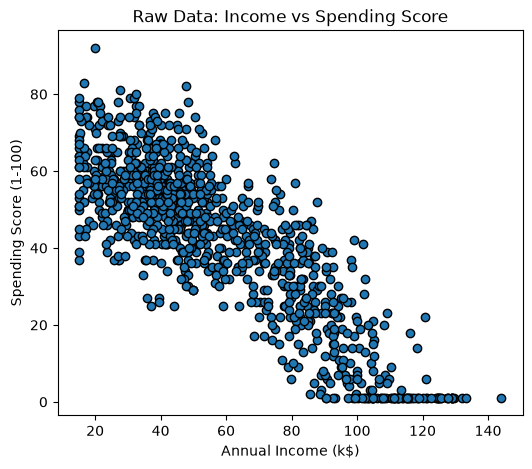

In [41]:
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], edgecolors='k')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Raw Data: Income vs Spending Score')
plt.show()

## 2. Scale features

K-Means and hierarchical clustering (Ward linkage) are both distance-based, so unscaled features would distort the clustering. `StandardScaler` centers each feature at mean 0 with standard deviation 1.

In [42]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[:5]

array([[ 0.09287166,  0.76448759],
       [-0.30890054, -0.28197653],
       [ 0.46320082, -0.83012439],
       [ 0.83352998, -0.6307979 ],
       [-0.52900183,  0.76448759]])

## 3. Elbow Method (using K-Means inertia)

Inertia = sum of squared distances of points to their closest centroid. It always decreases as K increases, but the rate of decrease slows down. The "elbow" — where the curve flattens — is a rough signal for a good K.

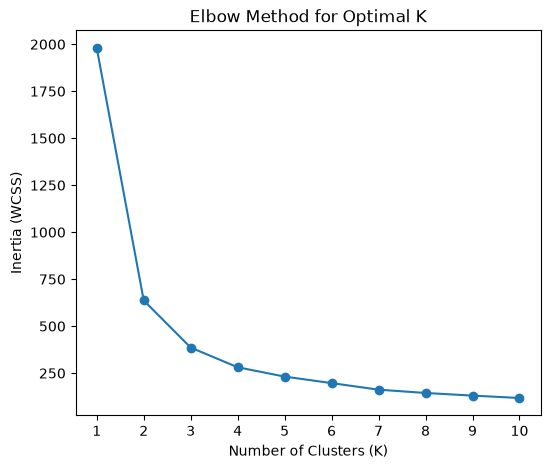

In [43]:
inertias = []
range_n_clusters = list(range(1, 11))

for n_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(6, 5))
plt.plot(range_n_clusters, inertias, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method for Optimal K')
plt.xticks(range_n_clusters)
plt.show()

## 4. Silhouette Score across different K values

Silhouette score measures how well-separated and cohesive clusters are, ranging from -1 (bad) to +1 (great). It requires at least 2 clusters, so we start at K=2. Unlike inertia, this score has a real maximum, so we can use it to automatically pick a K.

In [44]:
silhouette_avgs = []
range_n_clusters_sil = list(range(2, 11))

for n_clusters in range_n_clusters_sil:
    kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=42)
    cluster_labels = kmeans.fit_predict(X_scaled)
    sil_avg = silhouette_score(X_scaled, cluster_labels)
    silhouette_avgs.append(sil_avg)
    print(f"For n_clusters = {n_clusters}, average silhouette_score = {sil_avg:.3f}")

For n_clusters = 2, average silhouette_score = 0.586
For n_clusters = 3, average silhouette_score = 0.474
For n_clusters = 4, average silhouette_score = 0.395
For n_clusters = 5, average silhouette_score = 0.359
For n_clusters = 6, average silhouette_score = 0.368
For n_clusters = 7, average silhouette_score = 0.374
For n_clusters = 8, average silhouette_score = 0.358
For n_clusters = 9, average silhouette_score = 0.349
For n_clusters = 10, average silhouette_score = 0.345


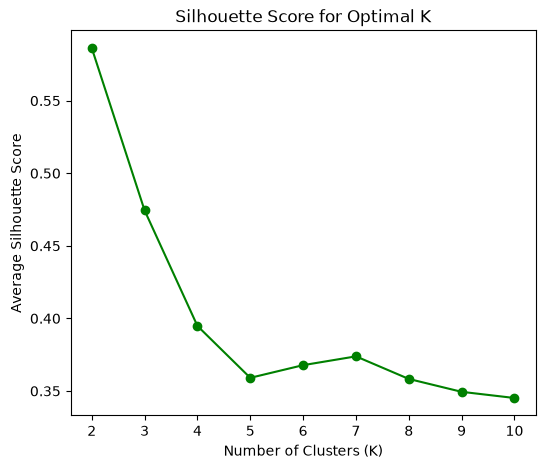

In [74]:
plt.figure(figsize=(6, 5))
plt.plot(range_n_clusters_sil, silhouette_avgs, marker='o', color='green')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Average Silhouette Score')
plt.title('Silhouette Score for Optimal K')
plt.xticks(range_n_clusters_sil)
plt.show()

In [75]:
best_k = range_n_clusters_sil[np.argmax(silhouette_avgs)]
print(f"Best K according to silhouette score: {best_k}")

Best K according to silhouette score: 2


## 5. Final K-Means model using the chosen K

This is the only K-Means fit whose labels we actually keep and use — everything above was diagnostic, just to help pick K.

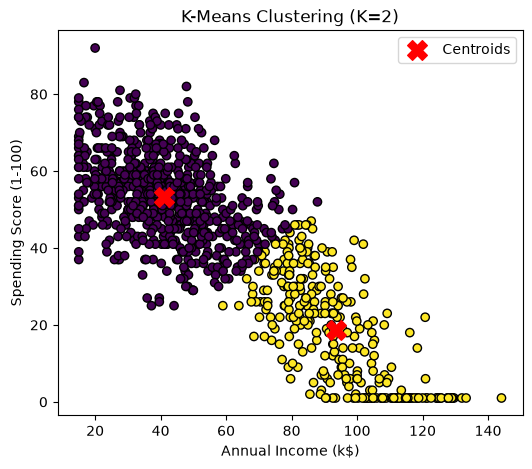

In [76]:
kmeans_final = KMeans(n_clusters=best_k, n_init=10, random_state=42)
df['Cluster_KMeans'] = kmeans_final.fit_predict(X_scaled)

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=df['Cluster_KMeans'], cmap='viridis', edgecolors='k')

# Plot centroids too (inverse-transform since centroids are in scaled space)
centroids_original = scaler.inverse_transform(kmeans_final.cluster_centers_)
plt.scatter(centroids_original[:, 0], centroids_original[:, 1],
            c='red', marker='X', s=200, label='Centroids')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title(f'K-Means Clustering (K={best_k})')
plt.legend()
plt.show()

## 6. Hierarchical Clustering: Dendrogram first

A dendrogram shows the entire merge history — every fusion from "all points separate" down to "one giant cluster." This is purely diagnostic; no cluster labels are extracted yet. You "cut" it horizontally at a height to decide on a number of clusters: the tallest vertical line you can cross without intersecting a horizontal merge line suggests a good cut point.

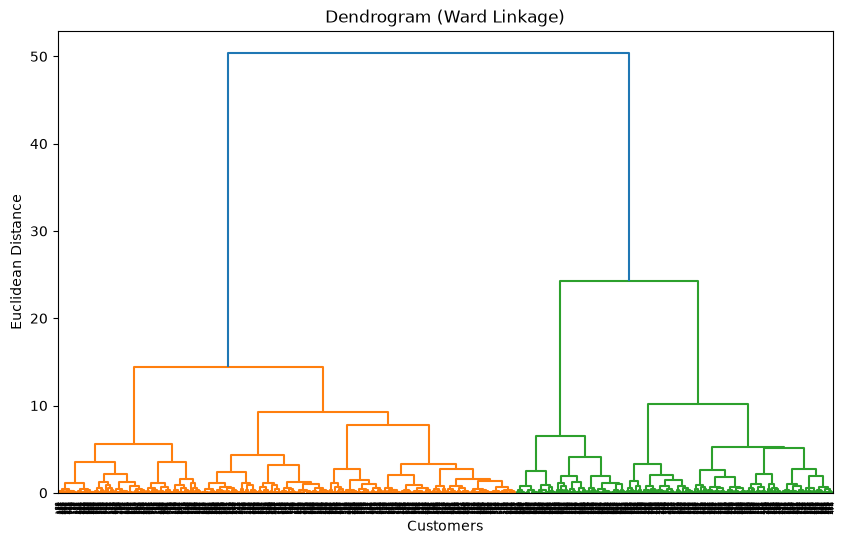

In [77]:
plt.figure(figsize=(10, 6))
Z = linkage(X_scaled, method='ward')
dendrogram(Z)
plt.title('Dendrogram (Ward Linkage)')
plt.xlabel('Customers')
plt.ylabel('Euclidean Distance')
plt.show()

## 7. Final Agglomerative (Hierarchical) Clustering model

This is the actual model that returns cluster labels. We reuse `best_k` from the silhouette analysis so the comparison with K-Means is fair (same number of clusters for both).

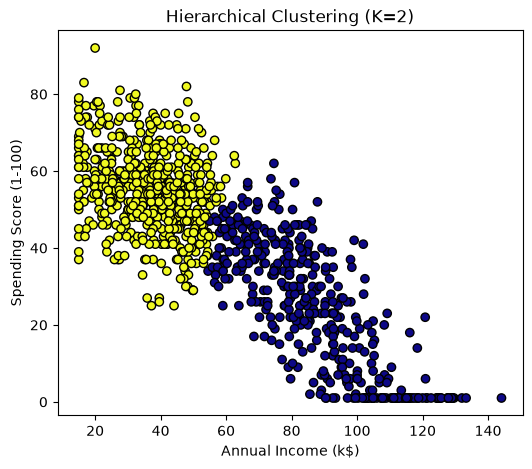

In [78]:
hc = AgglomerativeClustering(n_clusters=best_k, metric='euclidean', linkage='ward')
df['Cluster_HC'] = hc.fit_predict(X_scaled)

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=df['Cluster_HC'], cmap='plasma', edgecolors='k')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title(f'Hierarchical Clustering (K={best_k})')
plt.show()

## 8. Side-by-side comparison

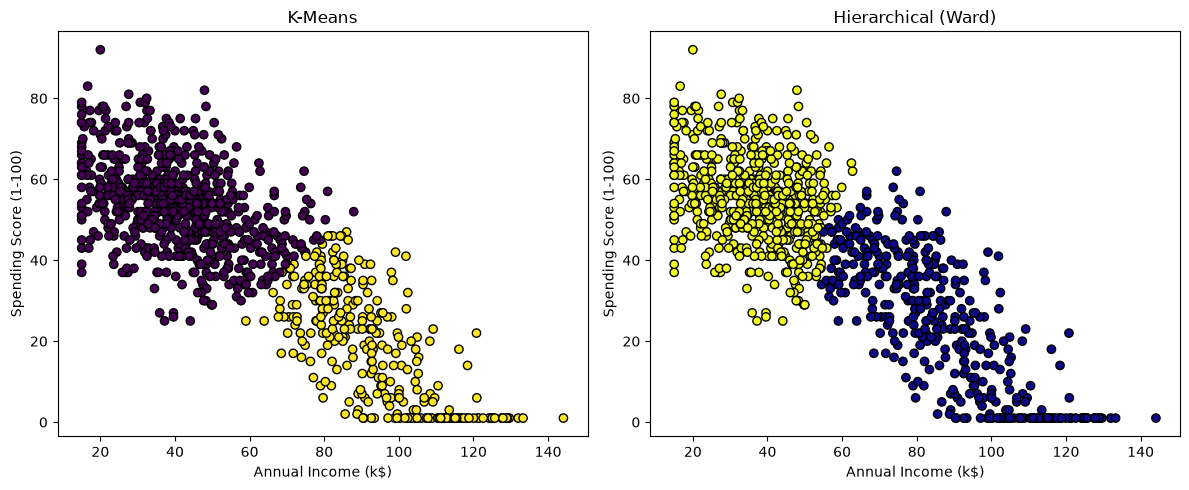

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(X[:, 0], X[:, 1], c=df['Cluster_KMeans'], cmap='viridis', edgecolors='k')
axes[0].set_title('K-Means')
axes[0].set_xlabel('Annual Income (k$)')
axes[0].set_ylabel('Spending Score (1-100)')

axes[1].scatter(X[:, 0], X[:, 1], c=df['Cluster_HC'], cmap='plasma', edgecolors='k')
axes[1].set_title('Hierarchical (Ward)')
axes[1].set_xlabel('Annual Income (k$)')
axes[1].set_ylabel('Spending Score (1-100)')

plt.tight_layout()
plt.show()

In [80]:
print("Cluster sizes (K-Means):")
print(df['Cluster_KMeans'].value_counts().sort_index())
print()
print("Cluster sizes (Hierarchical):")
print(df['Cluster_HC'].value_counts().sort_index())

Cluster sizes (K-Means):
Cluster_KMeans
0    684
1    306
Name: count, dtype: int64

Cluster sizes (Hierarchical):
Cluster_HC
0    405
1    585
Name: count, dtype: int64


In [81]:
sil_kmeans = silhouette_score(X_scaled, df['Cluster_KMeans'])
sil_hc = silhouette_score(X_scaled, df['Cluster_HC'])
print(f"Final silhouette score - K-Means: {sil_kmeans:.3f}")
print(f"Final silhouette score - Hierarchical: {sil_hc:.3f}")

Final silhouette score - K-Means: 0.586
Final silhouette score - Hierarchical: 0.537


In [82]:
print(df.columns.tolist())

['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Cluster_KMeans', 'Cluster_HC']


In [83]:
print(df.isnull().sum())

CustomerID                0
Gender                    2
Age                       6
Annual Income (k$)        0
Spending Score (1-100)    0
Cluster_KMeans            0
Cluster_HC                0
dtype: int64


In [84]:
df = df.dropna(subset=['Annual Income (k$)', 'Spending Score (1-100)'])
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values